In [ ]:
!pip install gensim scikit-learn matplotlib
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.8 MB/s eta 0:00:00


In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab') # Added to download the missing resource

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Sample corpus
corpus = [

"Natural Language Processing enables computers to understand human language.",
"Word embeddings represent words in a numerical form while preserving meaning.",
"NLP techniques are widely applied in translation and sentiment analysis.",
"Models like Word2Vec and GloVe help capture relationships between words."
]

In [ ]:
# Tokenize sentences
tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]
print(tokenized_corpus)


[['natural', 'language', 'processing', 'enables', 'computers', 'to', 'understand', 'human', 'language', '.'], ['word', 'embeddings', 'represent', 'words', 'in', 'a', 'numerical', 'form', 'while', 'preserving', 'meaning', '.'], ['nlp', 'techniques', 'are', 'widely', 'applied', 'in', 'translation', 'and', 'sentiment', 'analysis', '.'], ['models', 'like', 'word2vec', 'and', 'glove', 'help', 'capture', 'relationships', 'between', 'words', '.']]


In [ ]:
# Train Word2Vec model
model = Word2Vec(sentences=tokenized_corpus, vector_size=100, window=5, min_count=1, workers=4)


In [ ]:
# Save the model
model.save("word2vec.model")

In [ ]:
model = Word2Vec.load("word2vec.model")

In [ ]:
# Get vectors for a subset of words
words = list(model.wv.index_to_key)[:10]  # Select the first 10 words
print(words)
word_vectors = [model.wv[word] for word in words]
print(word_vectors)

['.', 'and', 'in', 'words', 'language', 'between', 'relationships', 'capture', 'help', 'glove']
[array([-5.3889723e-04,  2.4671780e-04,  5.1099709e-03,  9.0106009e-03,
       -9.3312506e-03, -7.1368944e-03,  6.4644250e-03,  8.9742858e-03,
       -5.0227763e-03, -3.7807727e-03,  7.3870975e-03, -1.5278582e-03,
       -4.5527266e-03,  6.5508634e-03, -4.8599415e-03, -1.8120274e-03,
        2.8775262e-03,  1.0007909e-03, -8.2902564e-03, -9.4591901e-03,
        7.3186979e-03,  5.0784363e-03,  6.7575341e-03,  7.6717389e-04,
        6.3475380e-03, -3.4067740e-03, -9.4813830e-04,  5.7658628e-03,
       -7.5254268e-03, -3.9448249e-03, -7.4979858e-03, -9.2478597e-04,
        9.5524201e-03, -7.3326780e-03, -2.3199907e-03, -1.9550866e-03,
        8.0872951e-03, -5.9353188e-03,  4.0697392e-05, -4.7519575e-03,
       -9.6184695e-03,  4.9994038e-03, -8.7569589e-03, -4.3882639e-03,
       -2.7184562e-05, -3.0500014e-04, -7.6605119e-03,  9.6148681e-03,
        5.0051827e-03,  9.2335716e-03, -8.1529105e-

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)
pca_result = pca.fit_transform(word_vectors)

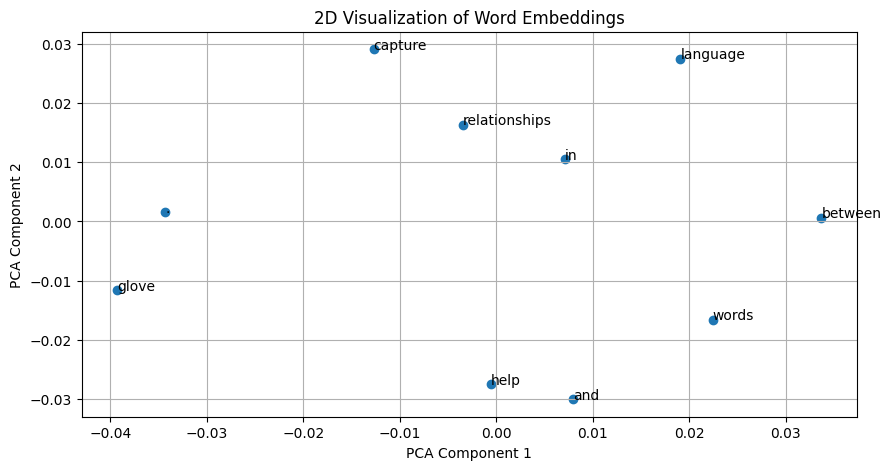

In [ ]:
import matplotlib.pyplot as plt

# Plot the words in 2D space
plt.figure(figsize=(10, 5))
plt.scatter(pca_result[:, 0], pca_result[:, 1])
# Annotate the points with the words
for i, word in enumerate(words):
    plt.annotate(word, xy=(pca_result[i, 0], pca_result[i, 1]))

plt.title("2D Visualization of Word Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()